#### 1. Setup

Imports, plot style, and pandas display options.


In [2]:
import warnings
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates
import json

from pathlib import Path
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_columns", 50)

#### 2. Config & Constants

Paths, station list, coordinates, forecast horizons, lookback window.


In [3]:
BASE_DIR = Path("AQI_DATA_024_025")
YEAR_DIRS = ["024", "025"]
STATIONS = ["Bhaktapur", "Khumaltar", "Ratnapark", "Shankhapark"]
PM25_COL = "PM2.5"

COORDS = {
    "Bhaktapur": (27.673762, 85.417528),
    "Khumaltar": (27.645986, 85.323808),
    "Ratnapark": (27.700000, 85.310000),
    "Shankhapark": (27.722654, 85.222836),
}

FORECAST_HORIZONS = [24, 48, 72]
LOOKBACK = 168

OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True)

EPA_UNHEALTHY = 55.5


#### 3. Helper Functions

`gap_lengths()` and `iqr_outlier_pct()`, reused across later sections.


In [4]:
def gap_lengths(is_missing):
    """Length of every run of consecutive missing values in a boolean series."""
    grp = (~is_missing).cumsum()
    runs = is_missing.groupby(grp).sum()
    return runs[runs > 0].values

def iqr_outlier_pct(s):
    """% of values in s falling outside the 1.5*IQR fence."""
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return 100 * ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()


#### 4. Load Raw Data

Reads each station/year CSV and combines into one raw table.


In [5]:
def load_file(year_dir, station):
    df = pd.read_csv(BASE_DIR / year_dir / f"{station}.csv", na_values=["NA"])
    df["timestamp"] = pd.to_datetime(df["Date"], format="mixed")
    df["station"] = station
    return df[["timestamp", PM25_COL, "station"]]

raw = pd.concat(
    [load_file(year, station) for year in YEAR_DIRS for station in STATIONS],
    ignore_index=True,
)


#### 5. Raw Dataset Overview

Shape, dtypes, and a peek at the raw rows before reindexing.


In [6]:
print("Raw dataset shape:", raw.shape)
print()
print(raw.dtypes)
raw.head()


Raw dataset shape: (68430, 3)

timestamp    datetime64[ns]
PM2.5               float64
station              object
dtype: object


,timestamp,PM2.5,station
0,2024-01-01 00:00:00,NaN,Bhaktapur
1,2024-01-01 01:00:00,NaN,Bhaktapur
2,2024-01-01 02:00:00,NaN,Bhaktapur
3,2024-01-01 03:00:00,NaN,Bhaktapur
4,2024-01-01 04:00:00,NaN,Bhaktapur


#### 6. Date Range Check

Start and end timestamp of the raw data.


In [7]:
print("Start date:", raw["timestamp"].min())
print("End date:", raw["timestamp"].max())

Start date: 2024-01-01 00:00:00
End date: 2025-12-31 23:00:00


#### 7. Timestamp / Duplicate Check

Invalid timestamps and duplicate (station, timestamp) rows.


In [8]:
print("Invalid timestamps:", raw["timestamp"].isna().sum())
print("Duplicate (station, timestamp) records:", raw.duplicated(["station", "timestamp"]).sum())

Invalid timestamps: 0
Duplicate (station, timestamp) records: 0


#### 8. Record Counts

Raw row count per station, before reindexing.


In [9]:
print("Raw record count per station (pre-reindex):")
print(raw.groupby("station").size())
print()
print("Total raw records (pre-reindex):", len(raw))


Raw record count per station (pre-reindex):
station
Bhaktapur      17544
Khumaltar      17544
Ratnapark      16144
Shankhapark    17198
dtype: int64

Total raw records (pre-reindex): 68430


#### 9. Reindex to Hourly Grid

Fills missing hours as NaN rows, merges station coordinates, saves combined CSV.


In [10]:
full_range = pd.date_range(raw["timestamp"].min(), raw["timestamp"].max(), freq="h")

reindexed = []
for station in STATIONS:
    s = raw.loc[raw.station == station].set_index("timestamp")[PM25_COL]
    s = s[~s.index.duplicated()].reindex(full_range)
    reindexed.append(pd.DataFrame({"timestamp": full_range, PM25_COL: s.values, "station": station}))
raw_full_grid = pd.concat(reindexed, ignore_index=True)

coord_df = pd.DataFrame(COORDS, index=["lat", "lon"]).T.reset_index(names="station")

aqi_data = (
    raw_full_grid.merge(coord_df, on="station")
       .sort_values(["station", "timestamp"])
       .reset_index(drop=True)
)

aqi_data.to_csv(OUT_DIR / "raw_hourly_combined.csv", index=False)

print(aqi_data.shape)
aqi_data.head()

(70176, 5)


,timestamp,PM2.5,station,lat,lon
0,2024-01-01 00:00:00,NaN,Bhaktapur,27.673762,85.417528
1,2024-01-01 01:00:00,NaN,Bhaktapur,27.673762,85.417528
2,2024-01-01 02:00:00,NaN,Bhaktapur,27.673762,85.417528
3,2024-01-01 03:00:00,NaN,Bhaktapur,27.673762,85.417528
4,2024-01-01 04:00:00,NaN,Bhaktapur,27.673762,85.417528


#### 10. Before/After Reindex

Compares record counts pre- and post-reindexing.


In [11]:
print("Before reindexing:")
print(f"  Total records: {len(raw)}")
print()
print("After reindexing:")
print(aqi_data.groupby('station').size().rename('records'))
print(f"  Total records: {len(aqi_data)}")


Before reindexing:
  Total records: 68430

After reindexing:
station
Bhaktapur      17544
Khumaltar      17544
Ratnapark      17544
Shankhapark    17544
Name: records, dtype: int64
  Total records: 70176


#### 11. Timeline Range per Station

Min/max timestamp for each station.


In [12]:
aqi_data.groupby("station")["timestamp"].agg(["min", "max"])


,min,max
station,,
Bhaktapur,2024-01-01,2025-12-31 23:00:00
Khumaltar,2024-01-01,2025-12-31 23:00:00
Ratnapark,2024-01-01,2025-12-31 23:00:00
Shankhapark,2024-01-01,2025-12-31 23:00:00


#### 12. Missing Data Summary

Overall missing count and percentage after reindexing.


In [13]:
print(f"Total records: {len(aqi_data)}")
print(f"Total stations: {aqi_data['station'].nunique()}")

missing_count = aqi_data[PM25_COL].isna().sum()
missing_percentage = aqi_data[PM25_COL].isna().mean() * 100

print(f"Total missing values: {missing_count}")
print(f"Overall missing percentage: {missing_percentage:.2f}%")

Total records: 70176
Total stations: 4
Total missing values: 9182
Overall missing percentage: 13.08%


#### 13. Per-Station Missing Summary

Missing % plus gap episode count and longest gap per station.


In [14]:
station_summary = (
    aqi_data.groupby("station")
    .agg(
        Total_Records=(PM25_COL, "size"),
        Missing_Values=(PM25_COL, lambda x: x.isna().sum()),
    )
)

station_summary["Missing_Percentage"] = (
    station_summary["Missing_Values"] / station_summary["Total_Records"] * 100
).round(2)

def gap_episode_stats(s):
    gl = gap_lengths(s.isna())
    return pd.Series({
        "Gap_Episodes": len(gl),
        "Longest_Gap_h": int(gl.max()) if len(gl) else 0,
    })

gap_stats = aqi_data.groupby("station")[PM25_COL].apply(gap_episode_stats).unstack()
station_summary = station_summary.join(gap_stats)

station_summary

,Total_Records,Missing_Values,Missing_Percentage,Gap_Episodes,Longest_Gap_h
station,,,,,
Bhaktapur,17544,3175,18.10,174,836
Khumaltar,17544,507,2.89,45,54
Ratnapark,17544,3533,20.14,48,1488
Shankhapark,17544,1967,11.21,29,1011


#### 14. Data Overview

Shape, column types, memory usage.

In [15]:
aqi_data.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70176 entries, 0 to 70175
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  70176 non-null  datetime64[ns]
 1   PM2.5      60994 non-null  float64       
 2   station    70176 non-null  object        
 3   lat        70176 non-null  float64       
 4   lon        70176 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 6.1 MB


#### 15. Duplicate Check

Confirms no duplicate rows or duplicate (station, timestamp) pairs.

In [16]:
print("duplicate rows:", aqi_data.duplicated().sum())
print("duplicate (station, timestamp):", aqi_data.duplicated(["station", "timestamp"]).sum())

duplicate rows: 0
duplicate (station, timestamp): 0


#### 16. Timestamp Sanity Checks

Dtype, no NaT, no duplicates, sorted per station.

In [17]:
checks = pd.Series({
    "datetime dtype": pd.api.types.is_datetime64_any_dtype(aqi_data["timestamp"]),
    "no NaT": aqi_data["timestamp"].notna().all(),
    "no dup (station, ts)": aqi_data.duplicated(["station", "timestamp"]).sum() == 0,
    "sorted per station": aqi_data.groupby("station")["timestamp"].apply(lambda s: s.is_monotonic_increasing).all(),
})
checks

datetime dtype          True
no NaT                  True
no dup (station, ts)    True
sorted per station      True
dtype: bool

#### 17. Missing Hours per Station

Count of NaN PM2.5 rows per station on the full grid.

In [18]:
full_data = aqi_data.copy()
full_data.groupby("station")[PM25_COL].apply(lambda s: s.isna().sum()).rename("missing_hours")

station
Bhaktapur      3175
Khumaltar       507
Ratnapark      3533
Shankhapark    1967
Name: missing_hours, dtype: int64

#### 18. Hourly Continuity Check

Confirms consecutive rows are exactly 1 hour apart.

In [19]:
gaps = full_data.groupby("station")["timestamp"].diff()
gaps.value_counts().head(5)

timestamp
0 days 01:00:00    70172
Name: count, dtype: int64

#### 19. Descriptive Statistics

Mean, std, quartiles, and skew of PM2.5 per station.

In [20]:
desc = aqi_data.groupby("station")[PM25_COL].describe()
desc["skew"] = aqi_data.groupby("station")[PM25_COL].apply(lambda s: stats.skew(s.dropna()))
desc

,count,mean,std,min,25%,50%,75%,max,skew
station,,,,,,,,,
Bhaktapur,14369.0,44.470916,35.096488,1.926667,16.950000,36.670000,62.471667,314.798332,1.564562
Khumaltar,17037.0,41.166101,31.871480,0.948333,14.210527,34.413560,60.215001,242.033901,1.125511
Ratnapark,14011.0,54.142521,37.729143,2.001667,21.409167,47.668333,79.042500,310.871667,0.930897
Shankhapark,15577.0,42.773666,31.893882,1.696552,17.435000,35.343333,59.545000,235.619999,1.387638


#### 20. Sensor Sanity Checks

Negative values, implausible highs, and stuck-sensor runs.

In [21]:
PHYSICAL_MAX = 1000.0

def longest_run(s):
    s = s.dropna()
    if s.empty:
        return 0
    return s.groupby(s.ne(s.shift()).cumsum()).transform("size").max()

anomalies = aqi_data.groupby("station")[PM25_COL].agg(
    negatives=lambda s: (s < 0).sum(),
    implausible=lambda s: (s > PHYSICAL_MAX).sum(),
    longest_run=longest_run,
)
anomalies

,negatives,implausible,longest_run
station,,,
Bhaktapur,0,0,1
Khumaltar,0,0,1
Ratnapark,0,0,1
Shankhapark,0,0,2


#### 21. Cross-Station Duplicate Values

Checks for identical PM2.5 readings across stations at the same hour.

In [22]:
wide = aqi_data.pivot_table(index="timestamp", columns="station", values=PM25_COL)
same_value_hits = wide.apply(lambda row: row.dropna().duplicated().any(), axis=1).sum()
print("timestamps with 2+ stations matching exactly:", same_value_hits)

timestamps with 2+ stations matching exactly: 0


#### 22. Data Quality Scorecard

Combines all profiling checks into one table per station.

In [23]:
rows = []
for s in STATIONS:
    full = full_data.loc[full_data.station == s, PM25_COL]
    ok = full.dropna()
    gl = gap_lengths(full.isna())
    rows.append({
        "station": s,
        "completeness_%": round(full.notna().mean() * 100, 1),
        "n_gaps": len(gl),
        "max_gap_h": int(gl.max()) if len(gl) else 0,
        "outlier_%": round(iqr_outlier_pct(ok), 2),
        "negatives": int((ok < 0).sum()),
        "implausible": int((ok > PHYSICAL_MAX).sum()),
        "mean_pm25": round(ok.mean(), 1),
        "%_hours_unhealthy": round((ok > EPA_UNHEALTHY).mean() * 100, 1),
    })

scorecard = pd.DataFrame(rows).set_index("station")
scorecard.to_csv(OUT_DIR / "data_quality_scorecard.csv")
scorecard

,completeness_%,n_gaps,max_gap_h,outlier_%,negatives,implausible,mean_pm25,%_hours_unhealthy
station,,,,,,,,
Bhaktapur,81.9,174,836,2.46,0,0,44.5,31.1
Khumaltar,97.1,45,54,1.36,0,0,41.2,28.8
Ratnapark,79.9,48,1488,0.78,0,0,54.1,43.0
Shankhapark,88.8,29,1011,2.34,0,0,42.8,28.3


#### 23. Time Features for EDA

Hour, day-of-week, month, season columns.

In [24]:
full_data["hour"] = full_data.timestamp.dt.hour
full_data["dow"] = full_data.timestamp.dt.dayofweek
full_data["day_name"] = full_data.timestamp.dt.day_name()
full_data["month"] = full_data.timestamp.dt.month
full_data["date"] = full_data.timestamp.dt.date

def season(m):
    return {12: "Winter", 1: "Winter", 2: "Winter",
            3: "Pre-monsoon", 4: "Pre-monsoon", 5: "Pre-monsoon",
            6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon"}.get(m, "Post-monsoon")

full_data["season"] = full_data.month.map(season)
valid = full_data.dropna(subset=[PM25_COL]).copy()

#### 24. Distribution Plot

Raw vs log1p histogram of PM2.5.

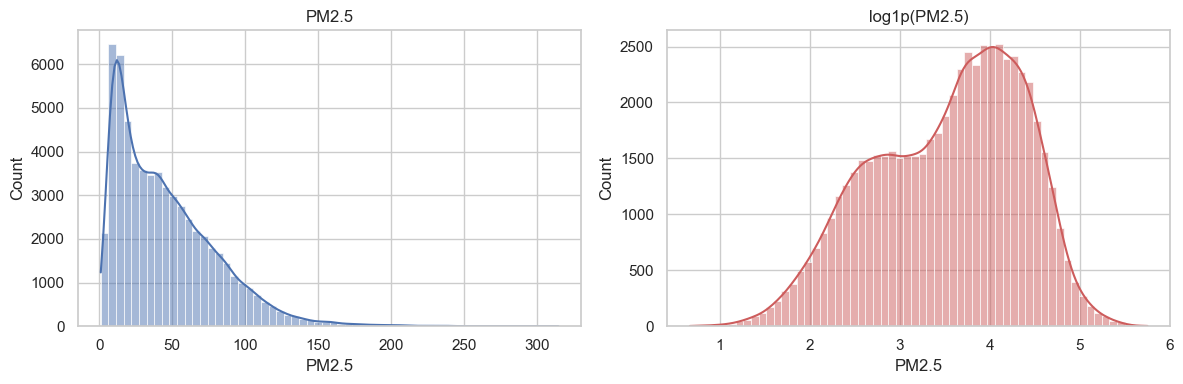

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(valid[PM25_COL], bins=60, kde=True, ax=ax[0])
sns.histplot(np.log1p(valid[PM25_COL]), bins=60, kde=True, ax=ax[1], color="indianred")
ax[0].set_title("PM2.5"); ax[1].set_title("log1p(PM2.5)")
plt.tight_layout();
plt.show()

#### 25. Boxplot by Station

PM2.5 spread per station plus IQR outlier percentage.

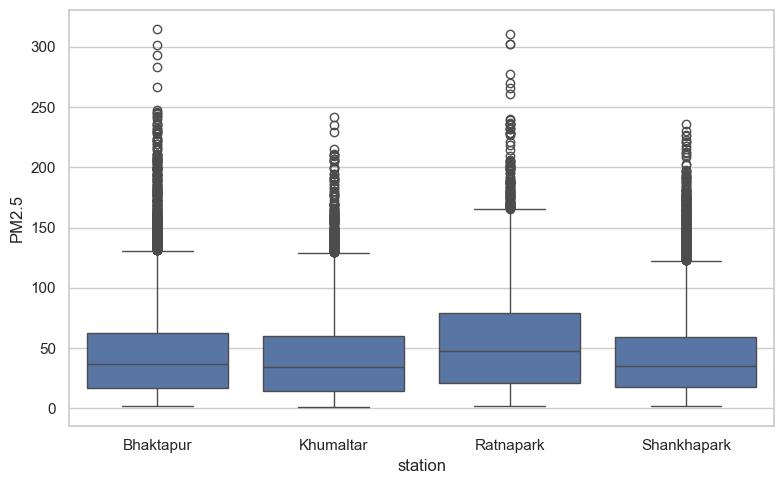

station
Bhaktapur      2.46
Khumaltar      1.36
Ratnapark      0.78
Shankhapark    2.34
Name: outlier_%, dtype: float64

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=valid, x="station", y=PM25_COL, ax=ax)
plt.tight_layout();
plt.show()

valid.groupby("station")[PM25_COL].apply(iqr_outlier_pct).round(2).rename("outlier_%")

#### 26. Full Time Series

One line plot per station across the whole period.

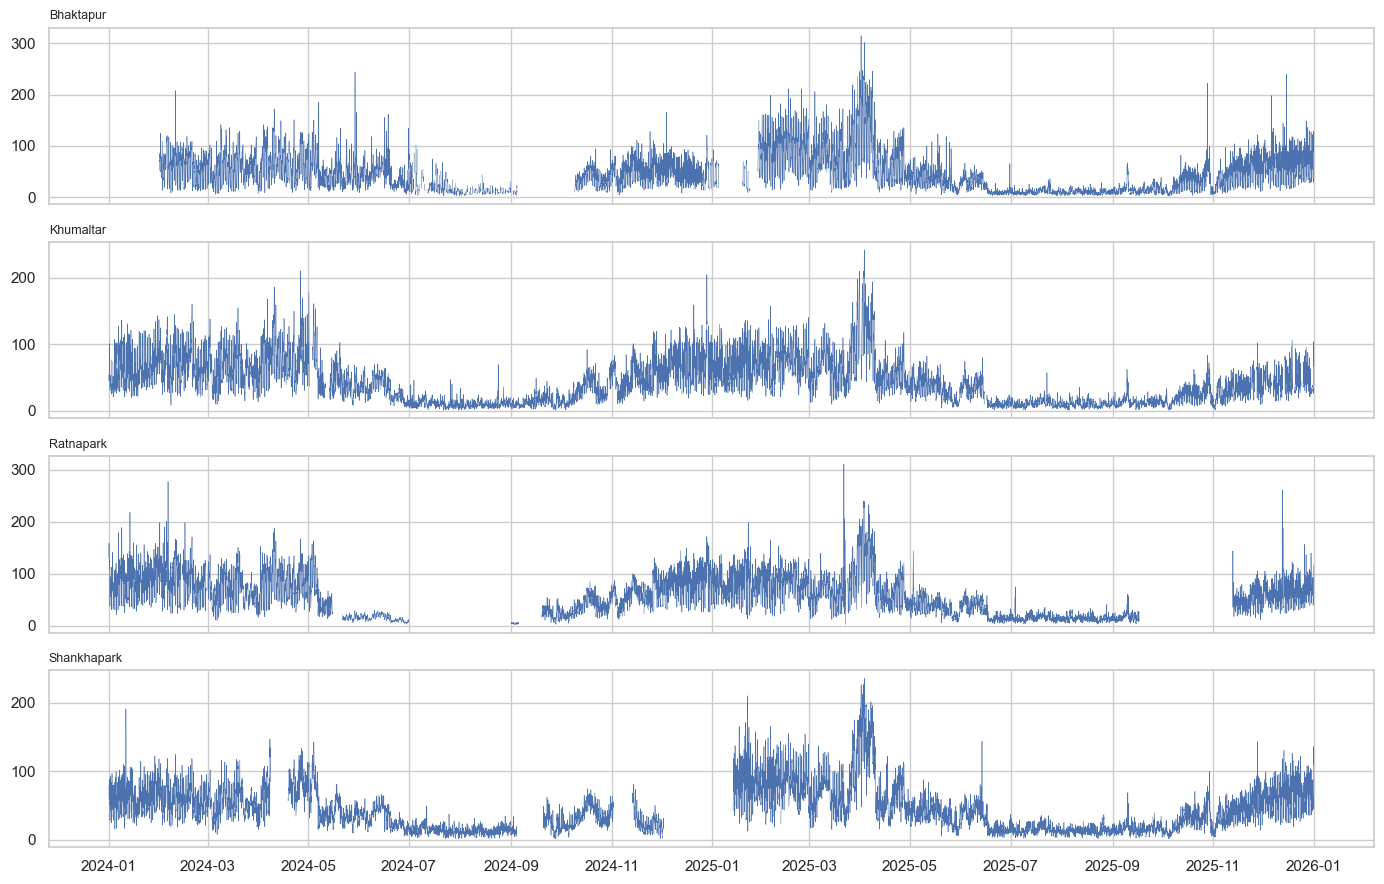

In [27]:
fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, s in zip(axes, STATIONS):
    d = full_data[full_data.station == s]
    ax.plot(d.timestamp, d[PM25_COL], lw=0.4)
    ax.set_title(s, loc="left", fontsize=9)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout();
plt.show()

#### 27. Daily Mean Trend

Daily average PM2.5 per station over time.

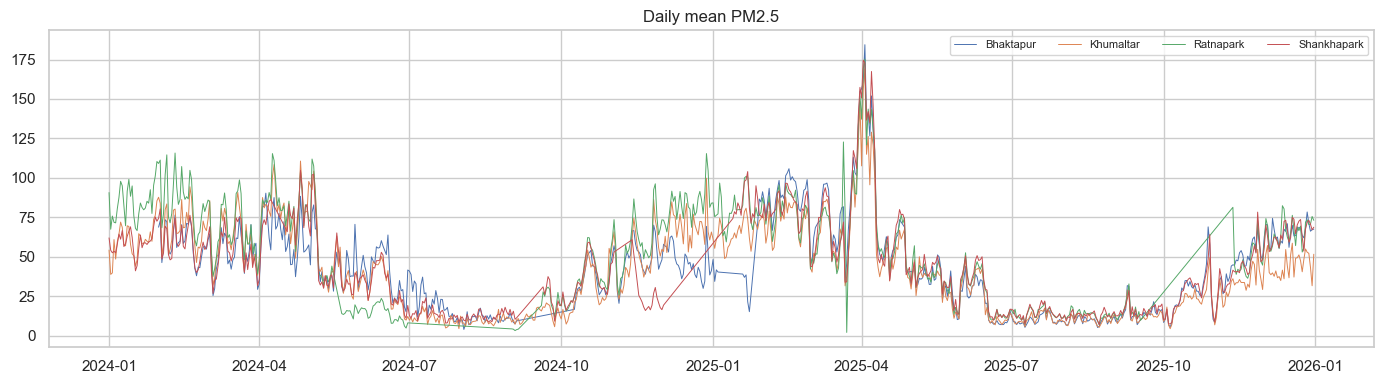

In [28]:
daily = valid.groupby(["station", "date"])[PM25_COL].mean().reset_index()
daily["date"] = pd.to_datetime(daily.date)
fig, ax = plt.subplots(figsize=(14, 4))
for s in STATIONS:
    d = daily[daily.station == s]
    ax.plot(d.date, d[PM25_COL], lw=0.7, label=s)
ax.legend(ncol=4, fontsize=8); ax.set_title("Daily mean PM2.5")
plt.tight_layout(); plt.show()

#### 28. Day-of-Week Pattern

PM2.5 boxplot by weekday.

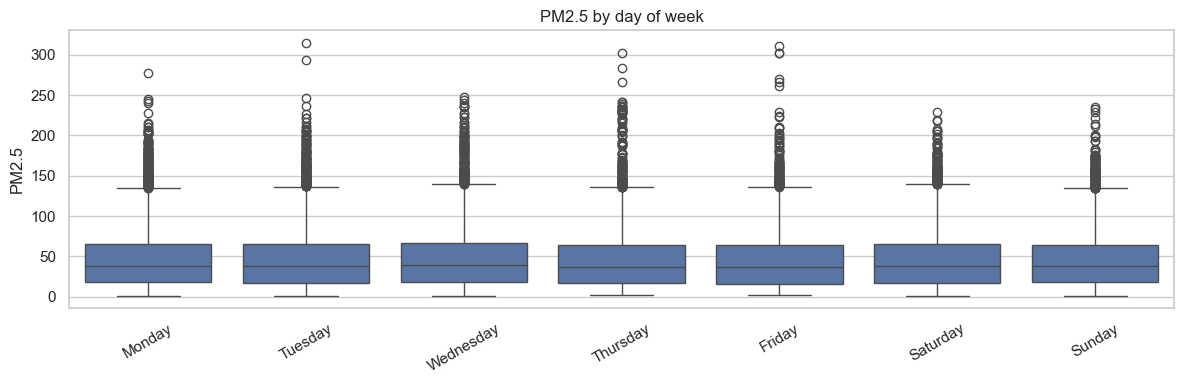

In [29]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.boxplot(data=valid, x="day_name", y=PM25_COL, order=order)
plt.xticks(rotation=30); plt.title("PM2.5 by day of week"); plt.xlabel("")
plt.tight_layout();
plt.show()

#### 29. Monthly Pattern

Mean PM2.5 by month per station.

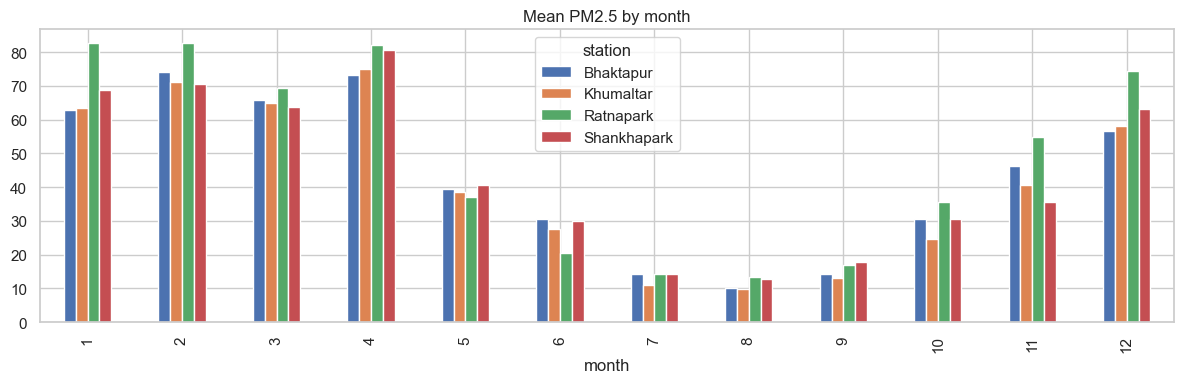

In [30]:
valid.groupby(["station", "month"])[PM25_COL].mean().unstack("station").plot(kind="bar", figsize=(12, 4))
plt.title("Mean PM2.5 by month");
plt.tight_layout();
plt.show()

#### 30. Seasonal Pattern

PM2.5 by season (winter/pre-monsoon/monsoon/post-monsoon) per station.

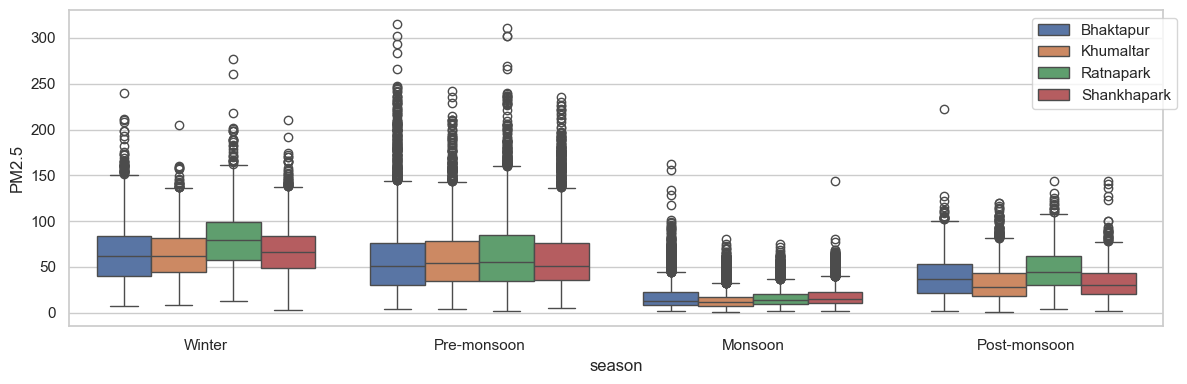

In [31]:
order = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]
sns.boxplot(data=valid, x="season", y=PM25_COL, hue="station", order=order)
plt.legend(bbox_to_anchor=(1.02, 1));
plt.tight_layout();
plt.show()

#### 31. Diurnal Pattern

Mean PM2.5 by hour of day, with std band.

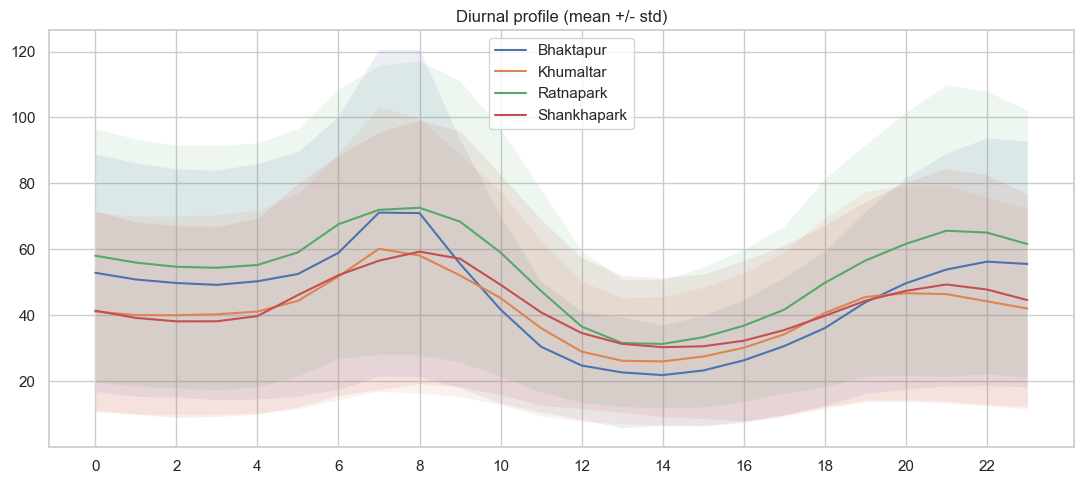

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
for s in STATIONS:
    g = valid[valid.station == s].groupby("hour")[PM25_COL].agg(["mean", "std"])
    ax.plot(g.index, g["mean"], label=s)
    ax.fill_between(g.index, g["mean"] - g["std"], g["mean"] + g["std"], alpha=0.1)
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.set_title("Diurnal profile (mean +/- std)")
plt.tight_layout();
plt.show()

#### 32. Month x Hour Heatmap

Mean PM2.5 across month and hour combinations.

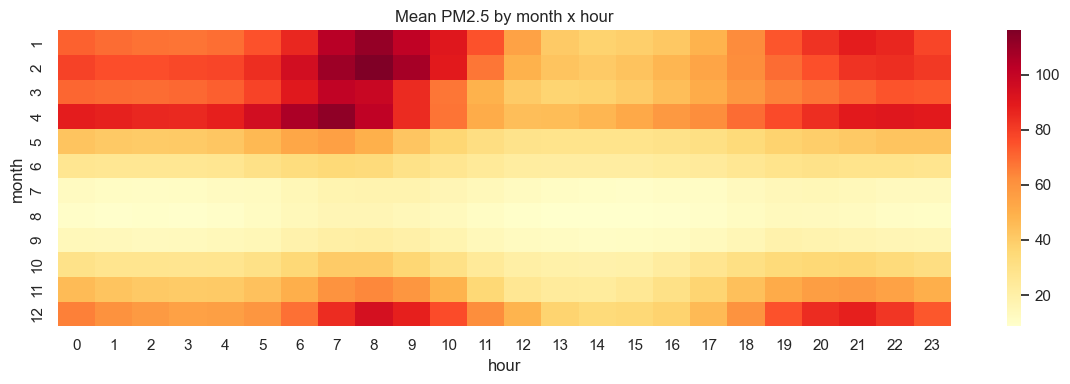

In [33]:
hm = valid.groupby(["month", "hour"])[PM25_COL].mean().unstack("hour")
sns.heatmap(hm, cmap="YlOrRd")
plt.title("Mean PM2.5 by month x hour"); 
plt.tight_layout();
plt.show()

#### 33. Trend/Seasonal/Residual Decomposition

Manual rolling-mean decomposition for Ratnapark, Jan-Feb 2025.

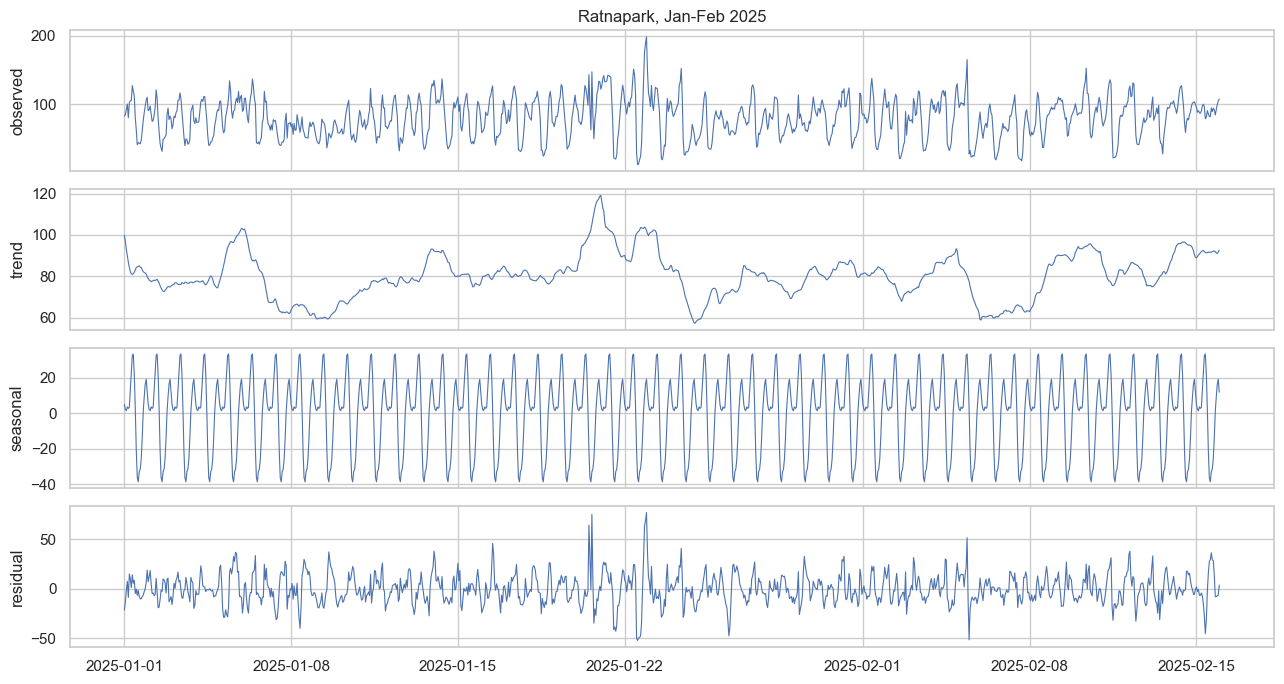

In [34]:
def decompose(s, period=24):
    s = s.interpolate(limit_direction="both")
    trend = s.rolling(period, center=True, min_periods=period // 2).mean()
    detrended = s - trend
    hour = np.arange(len(s)) % period
    profile = pd.Series(detrended.values, index=hour).groupby(level=0).mean()
    seasonal = pd.Series(hour, index=s.index).map(profile)
    return pd.DataFrame({"observed": s, "trend": trend, "seasonal": seasonal, "residual": detrended - seasonal})

series = full_data[full_data.station == "Ratnapark"].set_index("timestamp")[PM25_COL].loc["2025-01-01":"2025-02-15"]
d = decompose(series)
fig, axes = plt.subplots(4, 1, figsize=(13, 7), sharex=True)
for ax, col in zip(axes, d.columns):
    ax.plot(d.index, d[col], lw=0.8); ax.set_ylabel(col)
axes[0].set_title("Ratnapark, Jan-Feb 2025")
plt.tight_layout(); plt.show()

#### 34. Rolling Averages

24h and 7-day rolling mean over raw PM2.5 (Ratnapark).

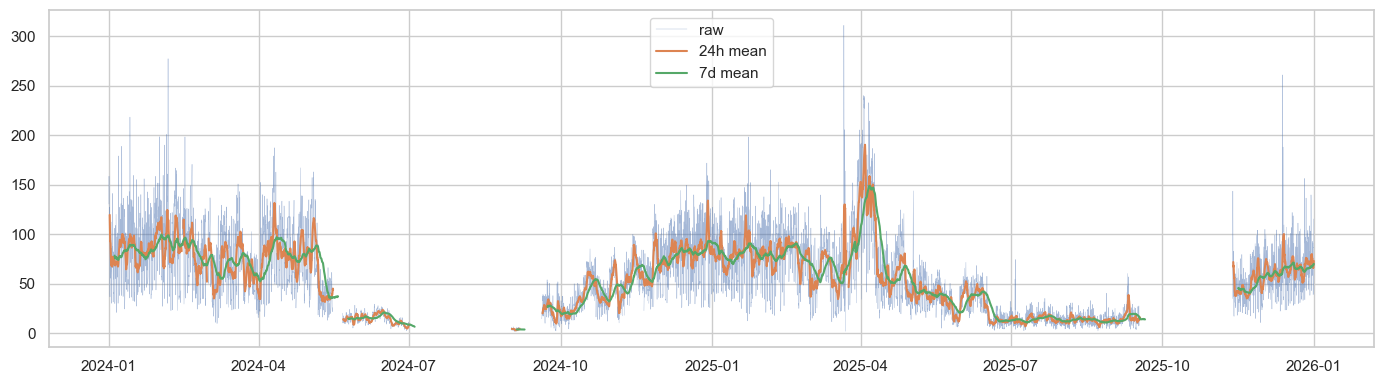

In [35]:
s = full_data[full_data.station == "Ratnapark"].set_index("timestamp")[PM25_COL]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s, lw=0.3, alpha=0.5, label="raw")
ax.plot(s.rolling(24, min_periods=12).mean(), label="24h mean")
ax.plot(s.rolling(168, min_periods=84).mean(), label="7d mean")
ax.legend();
plt.tight_layout();
plt.show()

#### 35. Station Correlation

Pairwise correlation heatmap across all stations.

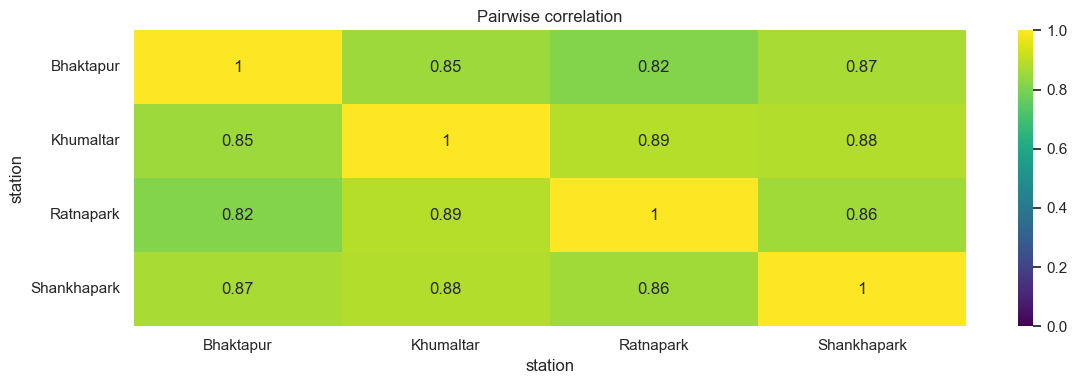

station,Bhaktapur,Khumaltar,Ratnapark,Shankhapark
station,,,,
Bhaktapur,1.000000,0.853505,0.816081,0.869810
Khumaltar,0.853505,1.000000,0.890170,0.884671
Ratnapark,0.816081,0.890170,1.000000,0.857191
Shankhapark,0.869810,0.884671,0.857191,1.000000


In [36]:
wide_full = full_data.pivot_table(index="timestamp", columns="station", values=PM25_COL)
corr = wide_full.corr()
sns.heatmap(corr, annot=True, cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise correlation");
plt.tight_layout(); plt.show()
corr

#### 36. Z-scored Overlay

Normalized PM2.5 series for all stations, Jan 2025.

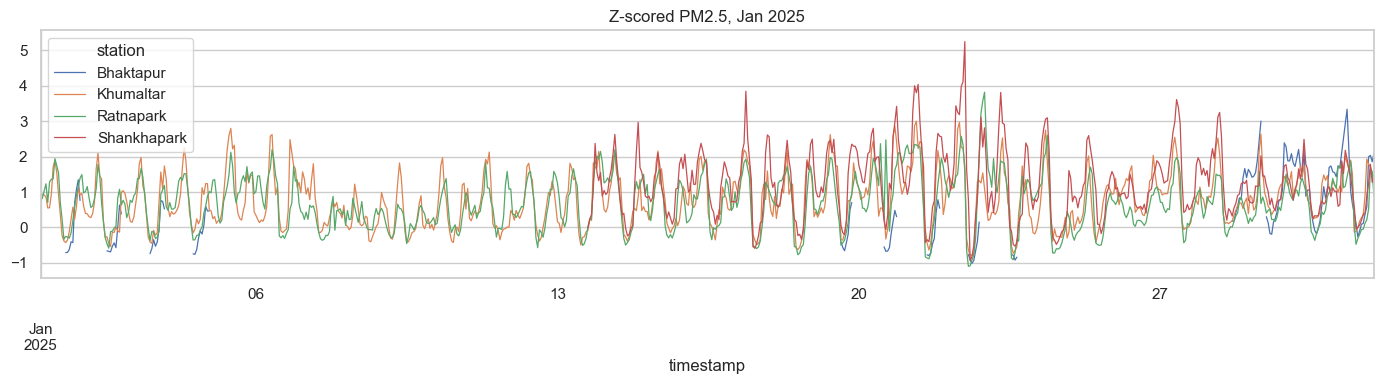

In [37]:
z = (wide_full - wide_full.mean()) / wide_full.std()
z.loc["2025-01-01":"2025-01-31"].plot(figsize=(14, 4), lw=0.9, title="Z-scored PM2.5, Jan 2025")
plt.tight_layout();
plt.show()

#### 37. Cross-Correlation (Lead/Lag)

Ratnapark vs other stations at different time lags.

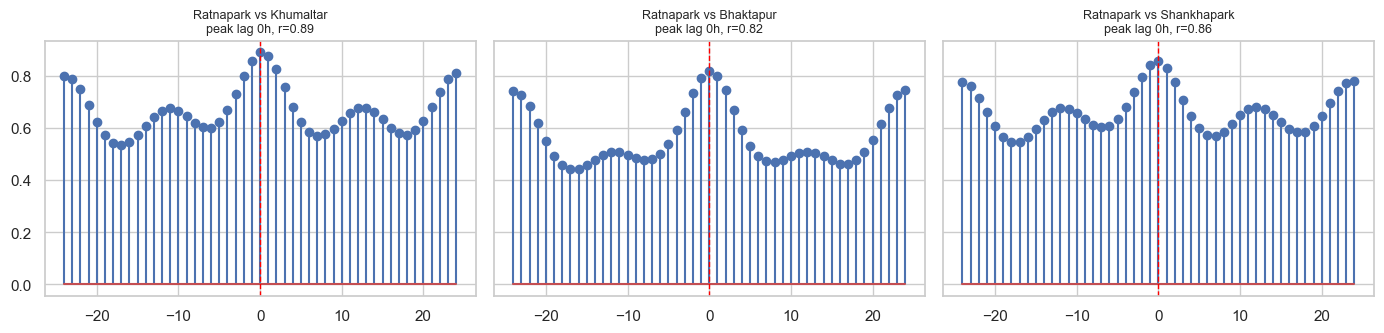

In [38]:
def ccf(a, b, max_lag=24):
    lags = range(-max_lag, max_lag + 1)
    return pd.Series([a.corr(b.shift(l)) for l in lags], index=lags)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, other in zip(axes, ["Khumaltar", "Bhaktapur", "Shankhapark"]):
    c = ccf(wide_full["Ratnapark"], wide_full[other])
    ax.stem(c.index, c.values)
    ax.axvline(c.idxmax(), color="red", ls="--", lw=1)
    ax.set_title(f"Ratnapark vs {other}\npeak lag {c.idxmax()}h, r={c.max():.2f}", fontsize=9)
plt.tight_layout(); plt.show()

#### 38. Missingness Heatmap

Where the gaps are, across stations and time.

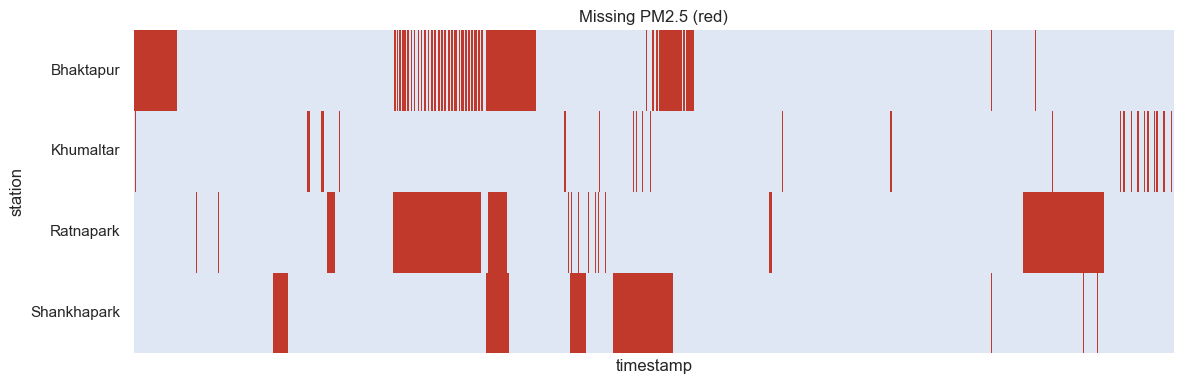

In [39]:
miss = wide_full.isna().astype(int).T
sns.heatmap(miss, cmap=["#dfe7f5", "#c0392b"], cbar=False)
plt.title("Missing PM2.5 (red)"); plt.xticks([]);
plt.tight_layout();
plt.show()

#### 39. Gap Length Distribution

Histogram of gap lengths per station (log scale).

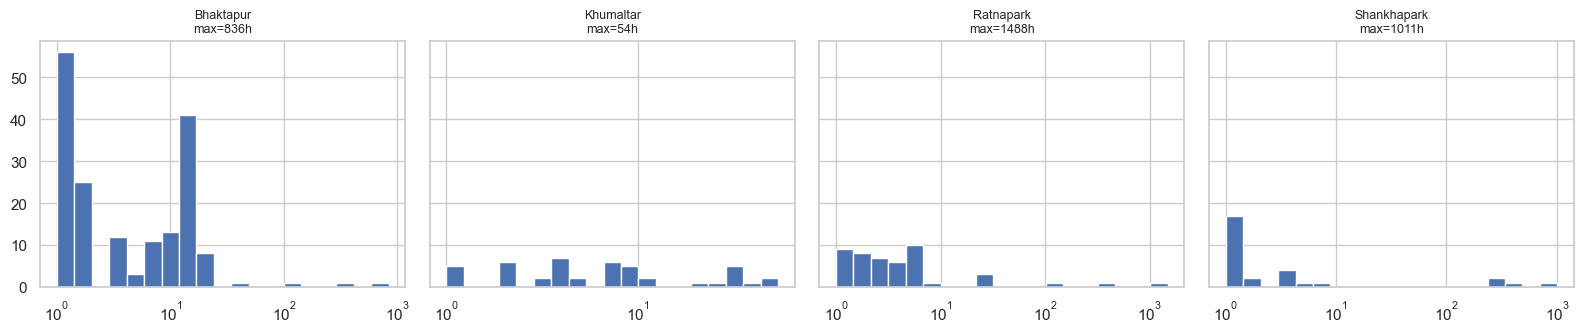

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for ax, s in zip(axes, STATIONS):
    gl = gap_lengths(wide_full[s].isna())
    ax.hist(gl, bins=np.logspace(0, np.log10(max(gl.max(), 2)), 20))
    ax.set_xscale("log"); ax.set_title(f"{s}\nmax={gl.max()}h", fontsize=9)
plt.tight_layout();
plt.show()

#### 40. EPA Exceedance Rate

% of hours above the EPA Unhealthy cutoff, per station.

In [41]:
exceed = valid.assign(
    over_epa=lambda d: d[PM25_COL] > EPA_UNHEALTHY,
)
exceed.groupby("station")["over_epa"].mean().mul(100).round(1)

station
Bhaktapur      31.1
Khumaltar      28.8
Ratnapark      43.0
Shankhapark    28.3
Name: over_epa, dtype: float64

#### 41. Monthly Exceedance Trend

% of hours over EPA Unhealthy, by month.

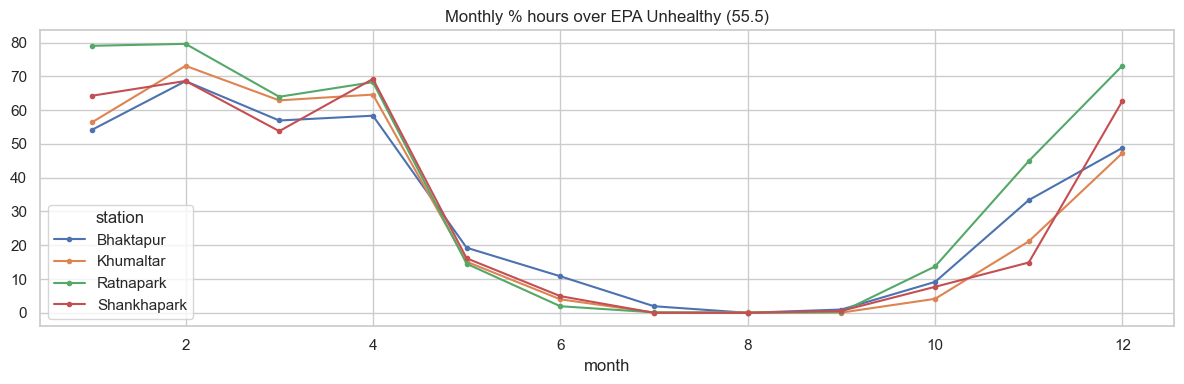

In [42]:
exceed.groupby(["station", "month"])["over_epa"].mean().mul(100).unstack("station").plot(
    marker="o", ms=3, figsize=(12, 4), title="Monthly % hours over EPA Unhealthy (55.5)"
)
plt.tight_layout(); plt.show()

#### 42. Gap Buckets

Splits gaps into short/medium/long hour buckets per station.

In [43]:
rows = []
for station in STATIONS:
    lengths = gap_lengths(full_data.loc[full_data.station == station, PM25_COL].isna())
    short_hours = lengths[lengths <= 3].sum()
    medium_hours = lengths[(lengths > 3) & (lengths <= 72)].sum()
    long_hours = lengths[lengths > 72].sum()
    rows.append({
        "station": station,
        "short_hours_1_3h": int(short_hours),
        "medium_hours_4_72h": int(medium_hours),
        "long_hours_72h_plus": int(long_hours),
    })

pd.DataFrame(rows).set_index("station")

,short_hours_1_3h,medium_hours_4_72h,long_hours_72h_plus
station,,,
Bhaktapur,127,1006,2042
Khumaltar,23,484,0
Ratnapark,46,162,3325
Shankhapark,33,13,1921


#### 43. Gap Episode Table

Every individual gap's start, end, and length; flags major (>72h) outages.

In [44]:
def gap_episode_table(station):
    s = full_data.loc[full_data.station == station].set_index("timestamp")[PM25_COL]
    is_missing = s.isna()
    run_id = (~is_missing).cumsum()
    rows = []
    for rid, chunk in s[is_missing].groupby(run_id[is_missing]):
        rows.append({
            "station": station,
            "gap_start": chunk.index.min(),
            "gap_end": chunk.index.max(),
            "missing_hours": len(chunk),
        })
    return pd.DataFrame(rows)

episodes = pd.concat([gap_episode_table(s) for s in STATIONS], ignore_index=True)
episodes = episodes.sort_values("missing_hours", ascending=False).reset_index(drop=True)
episodes["major_outage"] = episodes["missing_hours"] > 72

print(f"{len(episodes)} gap episodes total across all stations, "
      f"{episodes.major_outage.sum()} are major (>72h) outages:")
episodes[episodes.major_outage]

296 gap episodes total across all stations, 12 are major (>72h) outages:


,station,gap_start,gap_end,missing_hours,major_outage
0,Ratnapark,2024-07-01 00:00:00,2024-08-31 23:00:00,1488,True
1,Ratnapark,2025-09-17 03:00:00,2025-11-12 15:00:00,1357,True
2,Shankhapark,2024-12-02 14:00:00,2025-01-13 16:00:00,1011,True
3,Bhaktapur,2024-09-04 17:00:00,2024-10-09 12:00:00,836,True
4,Bhaktapur,2024-01-01 00:00:00,2024-01-31 15:00:00,736,True
5,Shankhapark,2024-09-04 15:00:00,2024-09-20 11:00:00,381,True
6,Bhaktapur,2025-01-04 23:00:00,2025-01-19 13:00:00,351,True
7,Ratnapark,2024-09-05 17:00:00,2024-09-19 13:00:00,333,True
8,Shankhapark,2024-11-02 06:00:00,2024-11-13 17:00:00,276,True
9,Shankhapark,2024-04-08 02:00:00,2024-04-18 14:00:00,253,True


#### 44. Missing Value Imputation

Seasonal blocked-stratified split (episode-proportional Class-4 allocation + purge embargo), then tiered fill: interpolate short gaps, climatology-fill medium gaps, leave long gaps as NaN.


In [45]:
model_data = full_data.sort_values(["station", "timestamp"]).reset_index(drop=True).copy()


SEASON_ORDER = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]
BASE_WEEKS = 2
HAZARD_PM25 = 125.5 
MAJOR_EPISODE_H = 200  
MEDIUM_EPISODE_H = 20
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.6, 0.2, 0.2
EMBARGO_H = max(FORECAST_HORIZONS) 

wide_raw = raw.pivot_table(index="timestamp", columns="station", values=PM25_COL).reindex(full_range)
roll24_raw = wide_raw.interpolate(method="time", limit=6, limit_area="inside").rolling(24, min_periods=18).mean()
hazard_hours = (roll24_raw >= HAZARD_PM25).sum(axis=1)
TOTAL_HAZARD = int(hazard_hours.sum())

cal = pd.DataFrame({"timestamp": full_range})
cal["season"] = cal.timestamp.dt.month.map(season)


def season_blocks(cal):
    grp = (cal.season != cal.season.shift()).cumsum()
    return [(g.season.iat[0], g.timestamp.min(), g.timestamp.max(), len(g))
            for _, g in cal.groupby(grp)]


blocks = season_blocks(cal)


is_hazard = hazard_hours > 0
dilated = pd.Series(is_hazard.rolling(49, center=True, min_periods=1).max().astype(bool).values, index=full_range)
egrp = (dilated != dilated.shift()).cumsum()
episodes = []
for _, g in dilated.groupby(egrp):
    if not g.iloc[0]:
        continue
    s, e = g.index.min(), g.index.max()
    hz = int(hazard_hours.loc[s:e].sum())
    if hz > 0:
        episodes.append({"start": s, "end": e, "hazard_h": hz})
episodes.sort(key=lambda ep: -ep["hazard_h"])

split = pd.Series("train", index=full_range)

# small val/test slice for every season too, not just the hazard-heavy ones
for szn in SEASON_ORDER:
    szn_blocks = [b for b in blocks if b[0] == szn]
    _, bstart, bend, _ = sorted(szn_blocks, key=lambda b: (b[3], b[1]))[-1]
    test_start = bend - pd.Timedelta(hours=BASE_WEEKS * 168 - 1)
    val_end = test_start - pd.Timedelta(hours=1)
    val_start = val_end - pd.Timedelta(hours=BASE_WEEKS * 168 - 1)
    split.loc[val_start:val_end] = "val"
    split.loc[test_start:bend] = "test"

# test takes the middle of the episode, val gets the tail end
running = {"train": 0, "val": 0, "test": 0}
for ep in episodes:
    if ep["hazard_h"] < MAJOR_EPISODE_H:
        continue
    s, e = ep["start"], ep["end"]
    cum = hazard_hours.loc[s:e].cumsum()
    train_cut = cum[cum >= TRAIN_FRAC * ep["hazard_h"]].index.min()
    val_cut = cum[cum >= (TRAIN_FRAC + VAL_FRAC) * ep["hazard_h"]].index.min()
    split.loc[s:train_cut] = "train"
    split.loc[train_cut + pd.Timedelta(hours=1):val_cut] = "test"
    split.loc[val_cut + pd.Timedelta(hours=1):e] = "val"
    running["train"] += int(hazard_hours.loc[s:train_cut].sum())
    running["test"] += int(hazard_hours.loc[train_cut + pd.Timedelta(hours=1):val_cut].sum())
    running["val"] += int(hazard_hours.loc[val_cut + pd.Timedelta(hours=1):e].sum())

target = {"train": TRAIN_FRAC * TOTAL_HAZARD, "val": VAL_FRAC * TOTAL_HAZARD, "test": TEST_FRAC * TOTAL_HAZARD}
for ep in sorted([e for e in episodes if MEDIUM_EPISODE_H <= e["hazard_h"] < MAJOR_EPISODE_H], key=lambda e: -e["hazard_h"]):
    deficits = {k: target[k] - running[k] for k in target}
    best = max(deficits, key=deficits.get)
    split.loc[ep["start"]:ep["end"]] = best
    running[best] += ep["hazard_h"]

for ep in episodes:  
    if ep["hazard_h"] < MEDIUM_EPISODE_H:
        split.loc[ep["start"]:ep["end"]] = "train"
        running["train"] += ep["hazard_h"]

vals = split.values
change_idx = np.where((vals[:-1] == "train") & np.isin(vals[1:], ["val", "test"]))[0]
for i in change_idx:
    lo = max(i - EMBARGO_H + 1, 0)
    window = split.iloc[lo:i + 1]
    split.iloc[lo:i + 1] = np.where(window == "train", "embargo", window)

model_data["split"] = model_data["timestamp"].map(split)

hz_by_split = {sp: int(hazard_hours[split.reindex(hazard_hours.index) == sp].sum())
               for sp in ["train", "val", "test", "embargo"]}
usable = hz_by_split["train"] + hz_by_split["val"] + hz_by_split["test"]
print(f"hazard (class-4-eligible) station-hours out of {TOTAL_HAZARD} total: {hz_by_split}")
print("share of usable hazard hours (excl. embargo), target ~60/20/20:")
print({k: round(hz_by_split[k] / usable * 100, 1) for k in ["train", "val", "test"]})
print()
print(model_data["split"].value_counts())
print()
print("season x split stratification check (row share, %):")
print(pd.crosstab(model_data["timestamp"].dt.month.map(season), model_data["split"],
                   normalize="index").mul(100).round(1).reindex(SEASON_ORDER)[["train", "val", "test", "embargo"]])

filled = []
for s in STATIONS:
    d = model_data[model_data.station == s].set_index("timestamp").copy()
    series = d[PM25_COL]

    run_id = (~series.isna()).cumsum()
    run_len = series.isna().groupby(run_id).transform("sum")

    out = series.copy()

    short = series.isna() & (run_len <= 3)
    interp = series.interpolate(method="time", limit=3, limit_area="inside")
    out[short] = interp[short]

    train_mask = (d["split"] == "train").to_numpy()
    clim = (series[train_mask].to_frame("v")
            .assign(h=d.index[train_mask].hour, m=d.index[train_mask].month)
            .groupby(["m", "h"])["v"].mean())
    medium = series.isna() & (run_len > 3) & (run_len <= 72)
    lookup = pd.Series(list(zip(d.index.month, d.index.hour)), index=d.index).map(clim.to_dict())
    out[medium] = lookup[medium]


    d["PM2.5_filled"] = out
    d["is_imputed"] = short | medium
    filled.append(d.reset_index())

model_data = pd.concat(filled, ignore_index=True)
print()
print("still missing (long gaps, left alone):")
print(model_data.groupby("station")["PM2.5_filled"].apply(lambda s: s.isna().sum()))


hazard (class-4-eligible) station-hours out of 800 total: {'train': 221, 'val': 153, 'test': 153, 'embargo': 273}
share of usable hazard hours (excl. embargo), target ~60/20/20:
{'train': 41.9, 'val': 29.0, 'test': 29.0}

split
train      57428
val         5696
test        5612
embargo     1440
Name: count, dtype: int64

season x split stratification check (row share, %):
split         train   val  test  embargo
timestamp                               
Winter         82.9   7.7   7.7      1.7
Pre-monsoon    78.4   9.4   8.9      3.3
Monsoon        87.3   5.7   5.7      1.2
Post-monsoon   74.6  11.5  11.5      2.5

still missing (long gaps, left alone):
station
Bhaktapur      2177
Khumaltar         0
Ratnapark      3325
Shankhapark    1921
Name: PM2.5_filled, dtype: int64


#### 45. Split Impact Check

Confirms long gaps don't disproportionately empty out any station's val/test sequences, and reports the embargo-purged hours.


In [ ]:
MAX_H = max(FORECAST_HORIZONS)

def split_impact(station):
    d = model_data.loc[model_data.station == station].reset_index(drop=True)
    target = d["PM2.5_filled"].to_numpy()
    kept, dropped = [], []
    for start in range(len(d) - LOOKBACK - MAX_H):
        end = start + LOOKBACK
        targets = [target[end + h - 1] for h in FORECAST_HORIZONS]
        anchor_split = d.loc[end - 1, "split"]
        if anchor_split == "embargo":
            continue  
        (dropped if np.isnan(targets).any() else kept).append(anchor_split)
    kept = pd.Series(kept).value_counts().reindex(["train", "val", "test"], fill_value=0)
    dropped = pd.Series(dropped).value_counts().reindex(["train", "val", "test"], fill_value=0)
    possible = kept + dropped
    return pd.DataFrame({
        "kept": kept, "dropped": dropped, "possible": possible,
        "pct_dropped": (dropped / possible * 100).round(1),
    })

for s in STATIONS:
    print(f" {s} ")
    print(split_impact(s))
    print()

embargo_hours = (model_data["split"] == "embargo").sum() // len(STATIONS)
print(f"embargo hours purged from every split (per station): {embargo_hours}")


 Bhaktapur 
        kept  dropped  possible  pct_dropped
train  12015     2102     14117         14.9
val     1418        6      1424          0.4
test    1403        0      1403          0.0

 Khumaltar 
        kept  dropped  possible  pct_dropped
train  14117        0     14117          0.0
val     1424        0      1424          0.0
test    1403        0      1403          0.0

 Ratnapark 
        kept  dropped  possible  pct_dropped
train  11285     2832     14117         20.1
val     1147      277      1424         19.5
test    1067      336      1403         23.9

 Shankhapark 
        kept  dropped  possible  pct_dropped
train  12004     2113     14117         15.0
val     1424        0      1424          0.0
test    1403        0      1403          0.0

embargo hours purged from every split (per station): 360


#### 46. EPA Health-Risk Classification

Maps PM2.5 to 4 merged EPA classes, with the decimal-truncation fix.

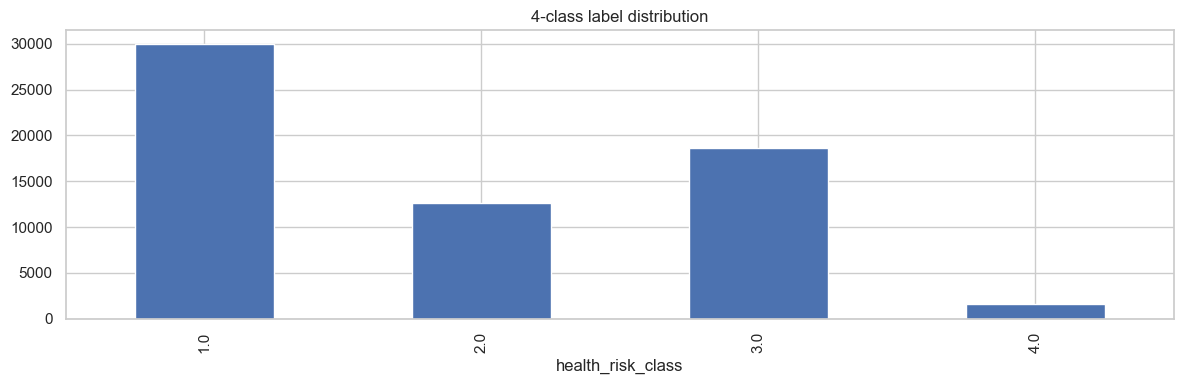

In [47]:
BREAKPOINTS = [(0, 9, "Good"), (9.1, 35.4, "Moderate"), (35.5, 55.4, "USG"),
               (55.5, 125.4, "Unhealthy"), (125.5, 225.4, "Very Unhealthy"), (225.5, 500.4, "Hazardous")]
MERGE = {"Good": 1, "Moderate": 1, "USG": 2, "Unhealthy": 3, "Very Unhealthy": 4, "Hazardous": 4}

def epa_category(c):
    if pd.isna(c):
        return np.nan
    c = np.floor(c * 10) / 10
    for lo, hi, label in BREAKPOINTS:
        if lo <= c <= hi:
            return label
    return "Hazardous"

model_data["health_risk_class"] = model_data["PM2.5_filled"].apply(epa_category).map(MERGE)
model_data["health_risk_class"].value_counts().sort_index().plot(kind="bar", title="4-class label distribution")
plt.tight_layout(); plt.show()

#### 47. Class Distribution (Hourly)

Count/percentage and imbalance ratio for the hourly-based class.

In [48]:
counts = model_data["health_risk_class"].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)
print(pd.DataFrame({"count": counts, "%": pct}))
print(f"imbalance ratio (max/min): {counts.max() / counts.min():.1f}")

                   count      %
health_risk_class              
1.0                29971  47.76
2.0                12594  20.07
3.0                18598  29.64
4.0                 1590   2.53
imbalance ratio (max/min): 18.8


#### 48. 24h vs Hourly Class Targets

Computes the primary (24h rolling avg) class label.

In [49]:
model_data["PM2.5_24h_avg"] = (
    model_data.groupby("station")["PM2.5_filled"]
    .transform(lambda s: s.rolling(24, min_periods=18).mean())
)
model_data["health_risk_class_24h"] = model_data["PM2.5_24h_avg"].apply(epa_category).map(MERGE)

#### 49. Class Distribution (24h, by Station)

Overall and per-station counts/percentages for the primary target.

In [50]:
counts_24h = model_data["health_risk_class_24h"].value_counts().sort_index()
pct_24h = (counts_24h / counts_24h.sum() * 100).round(2)
overall_24h = pd.DataFrame({"count": counts_24h.astype(int), "%": pct_24h})
print("Overall 4-class distribution (health_risk_class_24h):")
print(overall_24h)
print()
print(f"Imbalance ratio (max/min): {counts_24h.max() / counts_24h.min():.1f}")

station_24h = (
    model_data.dropna(subset=["health_risk_class_24h"])
    .groupby(["station", "health_risk_class_24h"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[1, 2, 3, 4], fill_value=0)
)
station_24h_pct = station_24h.div(station_24h.sum(axis=1), axis=0) * 100

print()
print("Station-wise counts (health_risk_class_24h):")
print(station_24h)
print()
print("Station-wise percentages (health_risk_class_24h):")
print(station_24h_pct.round(2))


Overall 4-class distribution (health_risk_class_24h):
                       count      %
health_risk_class_24h              
1.0                    26113  41.82
2.0                    14379  23.03
3.0                    21160  33.89
4.0                      791   1.27

Imbalance ratio (max/min): 33.0

Station-wise counts (health_risk_class_24h):
health_risk_class_24h     1     2     3    4
station                                     
Bhaktapur              6441  4184  4355  216
Khumaltar              7856  4063  5501  107
Ratnapark              4551  2520  6859  228
Shankhapark            7265  3612  4445  240

Station-wise percentages (health_risk_class_24h):
health_risk_class_24h      1      2      3     4
station                                         
Bhaktapur              42.39  27.53  28.66  1.42
Khumaltar              44.82  23.18  31.39  0.61
Ratnapark              32.14  17.80  48.45  1.61
Shankhapark            46.68  23.21  28.56  1.54


#### 50. Outlier Flagging

Flags IQR outliers per station/season; checks for physically impossible values.

In [51]:
n_bad = ((model_data["PM2.5_filled"] < 0) | (model_data["PM2.5_filled"] > PHYSICAL_MAX)).sum()
print("physically impossible values:", n_bad)

model_data["month"] = model_data.timestamp.dt.month
model_data["season"] = model_data.month.map(season)

def flag_outliers(g):
    q1, q3 = g.quantile([.25, .75])
    iqr = q3 - q1
    return (g < q1 - 1.5 * iqr) | (g > q3 + 1.5 * iqr)

model_data["is_outlier"] = model_data.groupby(["station", "season"])["PM2.5_filled"].transform(flag_outliers).fillna(False)
print("outliers flagged:", model_data.is_outlier.sum())

physically impossible values: 0
outliers flagged: 2775


#### 51. Feature Engineering

Cyclical time features, lags, and leakage-safe rolling stats.

In [52]:
model_data = model_data.sort_values(["station", "timestamp"]).reset_index(drop=True)

model_data["hour"] = model_data.timestamp.dt.hour
model_data["dow"] = model_data.timestamp.dt.dayofweek
model_data["hour_sin"] = np.sin(2 * np.pi * model_data.hour / 24)
model_data["hour_cos"] = np.cos(2 * np.pi * model_data.hour / 24)
model_data["dow_sin"] = np.sin(2 * np.pi * model_data.dow / 7)
model_data["dow_cos"] = np.cos(2 * np.pi * model_data.dow / 7)
model_data["month_sin"] = np.sin(2 * np.pi * model_data.month / 12)
model_data["month_cos"] = np.cos(2 * np.pi * model_data.month / 12)
model_data["is_weekend"] = model_data.dow.isin([5, 6]).astype(int)

LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
for lag in LAGS:
    model_data[f"lag_{lag}"] = model_data.groupby("station")["PM2.5_filled"].shift(lag)

shifted = model_data.groupby("station")["PM2.5_filled"].shift(1)
model_data["_s"] = shifted
for w in [3, 6, 24, 168]:
    model_data[f"roll_mean_{w}"] = model_data.groupby("station")["_s"].transform(lambda s: s.rolling(w, min_periods=max(2, w // 4)).mean())
    model_data[f"roll_std_{w}"] = model_data.groupby("station")["_s"].transform(lambda s: s.rolling(w, min_periods=max(2, w // 4)).std())
model_data = model_data.drop(columns="_s")

model_data.head()

,timestamp,PM2.5,station,lat,lon,hour,dow,day_name,month,date,season,split,PM2.5_filled,is_imputed,health_risk_class,PM2.5_24h_avg,health_risk_class_24h,is_outlier,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_24,roll_std_24,roll_mean_168,roll_std_168
0,2024-01-01 00:00:00,NaN,Bhaktapur,27.673762,85.417528,0,0,Monday,1,2024-01-01,Winter,train,NaN,False,NaN,NaN,NaN,False,0.000000,1.000000,0.0,1.0,0.5,0.866025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-01 01:00:00,NaN,Bhaktapur,27.673762,85.417528,1,0,Monday,1,2024-01-01,Winter,train,NaN,False,NaN,NaN,NaN,False,0.258819,0.965926,0.0,1.0,0.5,0.866025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-01 02:00:00,NaN,Bhaktapur,27.673762,85.417528,2,0,Monday,1,2024-01-01,Winter,train,NaN,False,NaN,NaN,NaN,False,0.500000,0.866025,0.0,1.0,0.5,0.866025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 03:00:00,NaN,Bhaktapur,27.673762,85.417528,3,0,Monday,1,2024-01-01,Winter,train,NaN,False,NaN,NaN,NaN,False,0.707107,0.707107,0.0,1.0,0.5,0.866025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 04:00:00,NaN,Bhaktapur,27.673762,85.417528,4,0,Monday,1,2024-01-01,Winter,train,NaN,False,NaN,NaN,NaN,False,0.866025,0.500000,0.0,1.0,0.5,0.866025,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 52. Feature Scaling

Fits MinMaxScaler on train split only, scales all rows, saves the scaler.

In [53]:
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = [
    "PM2.5_filled",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos", "is_weekend",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12", "lag_24", "lag_48", "lag_168",
    "roll_mean_3", "roll_mean_6", "roll_mean_24", "roll_mean_168",
    "roll_std_3", "roll_std_6", "roll_std_24", "roll_std_168",
]

train_rows = model_data.loc[model_data.split == "train", FEATURE_COLS].dropna()
print(f"train rows used to fit scaler: {len(train_rows):,} (of {(model_data.split == 'train').sum():,} train rows total)")

scaler = MinMaxScaler()
scaler.fit(train_rows)

scaled = (model_data[FEATURE_COLS].to_numpy() - scaler.data_min_) / scaler.data_range_
SCALED_COLS = [f"{c}_scaled" for c in FEATURE_COLS]
model_data[SCALED_COLS] = scaled

with open(OUT_DIR / "feature_scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "feature_cols": FEATURE_COLS}, f)

print(f"scaler fit on {len(FEATURE_COLS)} features, saved to {OUT_DIR / 'feature_scaler.pkl'}")
model_data[SCALED_COLS].describe().loc[["min", "max"]]

train rows used to fit scaler: 48,533 (of 57,428 train rows total)
scaler fit on 24 features, saved to processed\feature_scaler.pkl


,PM2.5_filled_scaled,hour_sin_scaled,hour_cos_scaled,dow_sin_scaled,dow_cos_scaled,month_sin_scaled,month_cos_scaled,is_weekend_scaled,lag_1_scaled,lag_2_scaled,lag_3_scaled,lag_6_scaled,lag_12_scaled,lag_24_scaled,lag_48_scaled,lag_168_scaled,roll_mean_3_scaled,roll_mean_6_scaled,roll_mean_24_scaled,roll_mean_168_scaled,roll_std_3_scaled,roll_std_6_scaled,roll_std_24_scaled,roll_std_168_scaled
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.0,-0.005804,-0.027752,-0.000052,-0.001088,-0.003866,-0.021951
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.01267,1.01267,1.01267,1.01267,1.01267,1.0,1.0,1.141445,1.125304,1.000000,1.000000,1.000000,1.113352


#### 53. Build LSTM Sequences

168h windows with 3-horizon targets, saved per station as `.npz`.

In [54]:
FEAT_SCALED_COLS = [f"{c}_scaled" for c in FEATURE_COLS]
MAX_H = max(FORECAST_HORIZONS)

def build_sequences(station):
    d = model_data.loc[model_data.station == station].reset_index(drop=True)
    feat = d[FEAT_SCALED_COLS].to_numpy(dtype=np.float64)
    pm25 = d["PM2.5_filled"].to_numpy(dtype=np.float64)
    cls_24h = d["health_risk_class_24h"].to_numpy(dtype=np.float64)
    cls_hourly = d["health_risk_class"].to_numpy(dtype=np.float64)
    splits = d["split"].to_numpy()
    ts = d["timestamp"].to_numpy()

    n = len(d)
    X_list, y_pm25_list, y_cls_list, y_cls_hourly_list = [], [], [], []
    anchor_ts_list, anchor_split_list = [], []
    for start in range(n - LOOKBACK - MAX_H):
        end = start + LOOKBACK
        anchor_split = splits[end - 1]
        if anchor_split == "embargo":
            continue  # purge buffer: never anchor a sequence here
        window = feat[start:end]
        target_idx = [end + h - 1 for h in FORECAST_HORIZONS]
        t_pm25 = pm25[target_idx]
        t_cls_24h = cls_24h[target_idx]
        t_cls_hourly = cls_hourly[target_idx]
        if np.isnan(window).any() or np.isnan(t_pm25).any() or np.isnan(t_cls_24h).any():
            continue
        X_list.append(window)
        y_pm25_list.append(t_pm25)
        y_cls_list.append(t_cls_24h)
        y_cls_hourly_list.append(t_cls_hourly)
        anchor_ts_list.append(ts[end - 1])
        anchor_split_list.append(anchor_split)

    return {
        "X": np.array(X_list, dtype=np.float32),
        "y_pm25": np.array(y_pm25_list, dtype=np.float32),
        "y_class": np.array(y_cls_list, dtype=np.int64),
        "y_class_hourly": np.array(y_cls_hourly_list, dtype=np.float32),
        "anchor_timestamp": np.array(anchor_ts_list, dtype="datetime64[ns]"),
        "split": np.array(anchor_split_list),
    }

sequence_summary = []
station_sequences = {}
for station in STATIONS:
    seq = build_sequences(station)
    station_sequences[station] = seq
    np.savez(
        OUT_DIR / f"sequences_{station}.npz",
        X=seq["X"], y_pm25=seq["y_pm25"], y_class=seq["y_class"], y_class_hourly=seq["y_class_hourly"],
        anchor_timestamp=seq["anchor_timestamp"], split=seq["split"],
        feature_names=np.array(FEATURE_COLS), horizons=np.array(FORECAST_HORIZONS),
    )
    for sp in ["train", "val", "test"]:
        mask = seq["split"] == sp
        sequence_summary.append({"station": station, "split": sp, "n_sequences": int(mask.sum())})

sequence_summary_df = (
    pd.DataFrame(sequence_summary)
    .pivot(index="station", columns="split", values="n_sequences")[["train", "val", "test"]]
)
print("sequence windows kept per station / split (primary target = 24h-avg class; "
      f"X shape per station: (n, 168, {len(FEATURE_COLS)}) ):")
sequence_summary_df


sequence windows kept per station / split (primary target = 24h-avg class; X shape per station: (n, 168, 24) ):


split,train,val,test
station,,,
Bhaktapur,11153,1026,1203
Khumaltar,13949,1424,1403
Ratnapark,10334,1019,836
Shankhapark,10400,1424,1403


#### 54. Class Weights

Balanced class weights from train-split labels, saved for the weighted loss.

In [55]:
train_y_class = np.concatenate([
    station_sequences[s]["y_class"][station_sequences[s]["split"] == "train"].ravel()
    for s in STATIONS
])
classes = np.array([1, 2, 3, 4])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_y_class)
class_weights = {int(c): float(w) for c, w in zip(classes, weights)}

print("train-split class distribution (pooled across stations & horizons):")
print(pd.Series(train_y_class).value_counts().sort_index())
print()
print("balanced class weights:", class_weights)

with open(OUT_DIR / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

train-split class distribution (pooled across stations & horizons):
1    58530
2    30867
3    46944
4     1167
Name: count, dtype: int64

balanced class weights: {1: 0.5873398257303947, 2: 1.1137136747983283, 3: 0.7322980572597138, 4: 29.457583547557842}


#### 55. Class Distribution — Train / Val / Test (Sequence-Level)

Per-class sequence counts in each split, pooled across stations and all 3 forecast horizons, on the **primary 24h-avg target** (`y_class`) — the same pooling convention used for the §54 class weights. Missing until now: §54 only reported the train-side distribution; this adds val/test so the seasonal blocked-stratified split's effect on Class 4 is visible end to end.

In [56]:
CLASSES = [1, 2, 3, 4]
counts = {sp: {c: 0 for c in CLASSES} for sp in ["train", "val", "test"]}
for station in STATIONS:
    d = np.load(OUT_DIR / f"sequences_{station}.npz", allow_pickle=True)
    y_class, split = d["y_class"], d["split"]  # y_class: primary 24h-avg target, shape (n, 3 horizons)
    for sp in ["train", "val", "test"]:
        vals = y_class[split == sp].ravel()
        for c in CLASSES:
            counts[sp][c] += int((vals == c).sum())

table = pd.DataFrame(counts).reindex(CLASSES)[["train", "val", "test"]]
table["Total"] = table.sum(axis=1)
table.loc["Total"] = table.sum()

pct = pd.DataFrame(counts).reindex(CLASSES)[["train", "val", "test"]]
pct = (pct / pct.sum(axis=0) * 100).round(2)

print("Sequence-level class counts (pooled across stations & all 3 horizons, primary 24h-avg target y_class):")
print(table)
print()
print("Column-wise % (share of each split that is each class):")
print(pct)

assert (table.loc[CLASSES, ["train", "val", "test"]].sum(axis=1) == table.loc[CLASSES, "Total"]).all(), \
    "Train + Val + Test must equal Total per class"
print()
print("Check passed: Train + Val + Test == Total for every class.")

Sequence-level class counts (pooled across stations & all 3 horizons, primary 24h-avg target y_class):
        train    val   test   Total
1       58530   5504   6123   70157
2       30867   5299   3326   39492
3       46944   3761   4616   55321
4        1167    115    470    1752
Total  137508  14679  14535  166722

Column-wise % (share of each split that is each class):
   train    val   test
1  42.56  37.50  42.13
2  22.45  36.10  22.88
3  34.14  25.62  31.76
4   0.85   0.78   3.23

Check passed: Train + Val + Test == Total for every class.


#### 56. Processed Files Manifest

Lists everything saved under `processed/` with file sizes.

In [57]:
manifest = []
for f in sorted(OUT_DIR.glob("*")):
    manifest.append({"file": f.name, "size_kb": round(f.stat().st_size / 1024, 1)})
pd.DataFrame(manifest)

,file,size_kb
0,class_weights.json,0.1
1,data_quality_scorecard.csv,0.3
2,feature_scaler.pkl,2.0
3,raw_hourly_combined.csv,4089.9
4,sequences_Bhaktapur.npz,211762.9
5,sequences_Khumaltar.npz,265470.3
6,sequences_Ratnapark.npz,192884.6
7,sequences_Shankhapark.npz,209310.2
